In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

In [35]:
tf.keras.utils.set_random_seed(42)
df = pd.read_csv(r"C:\Users\2003n\Downloads\adult.csv")

df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [36]:
# Reload original data
df = pd.read_csv(r"C:\Users\2003n\Downloads\adult.csv")

# Make a copy
df = df.copy()

# Remove extra spaces from string columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# Replace ? with NaN
df = df.replace("?", np.nan)

# Drop rows with missing values
df = df.dropna()

# Convert target to binary
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})

# Convert gender to binary
df["gender"] = df["gender"].map({"Female": 0, "Male": 1})

# Drop fnlwgt if it exists
if "fnlwgt" in df.columns:
    df = df.drop(columns=["fnlwgt"])

# Check that data is not empty
print(df.shape)
df.head()

(45222, 14)


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,1,0,0,30,United-States,0


In [37]:
# Feature engineering

# Net capital activity
df["capital-net"] = df["capital-gain"] - df["capital-loss"]

# Binary capital activity indicators
df["has-capital-gain"] = (df["capital-gain"] > 0).astype(int)
df["has-capital-loss"] = (df["capital-loss"] > 0).astype(int)

# Age and education interaction
df["age_education_interaction"] = df["age"] * df["educational-num"]

# Log transformation of net capital activity
# Clip lower bound to 0 so log1p can handle the values
capital_net_clipped = df["capital-net"].clip(lower=0)
df["capital_net_log"] = np.log1p(capital_net_clipped)

# Age and marriage interaction
df["age_married"] = df["age"] * (df["marital-status"] == "Married-civ-spouse").astype(int)

df.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,capital-net,has-capital-gain,has-capital-loss,age_education_interaction,capital_net_log,age_married
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0,0,0,0,175,0.000000,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0,0,0,0,342,0.000000,38
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1,0,0,0,336,0.000000,28
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1,7688,1,0,440,8.947546,44
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,1,0,0,30,United-States,0,0,0,0,204,0.000000,0


In [38]:
X = df.drop("income", axis=1)
y = df["income"]

# First split into training and test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split training into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

In [39]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_features, categorical_features

(Index(['age', 'educational-num', 'gender', 'capital-gain', 'capital-loss',
        'hours-per-week', 'capital-net', 'has-capital-gain', 'has-capital-loss',
        'age_education_interaction', 'capital_net_log', 'age_married'],
       dtype='object'),
 Index(['workclass', 'education', 'marital-status', 'occupation',
        'relationship', 'race', 'native-country'],
       dtype='object'))

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrices to dense arrays if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_val_processed = X_val_processed.toarray()
    X_test_processed = X_test_processed.toarray()

X_train_processed.shape

(28941, 108)

In [41]:
def build_model(
    input_dim,
    hidden_layers=[32],
    dropout_rate=0.0,
    learning_rate=0.001,
    l2_strength=0.0
):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(
            layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizers.l2(l2_strength)
            )
        )

        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )

    return model

In [42]:
def evaluate_model(model, X_data, y_data):
    y_prob = model.predict(X_data).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    results = {
        "Accuracy": accuracy_score(y_data, y_pred),
        "Precision": precision_score(y_data, y_pred),
        "Recall": recall_score(y_data, y_pred),
        "F1 Score": f1_score(y_data, y_pred),
        "ROC AUC": roc_auc_score(y_data, y_prob)
    }

    return results

In [43]:
def plot_training_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [44]:
input_dim = X_train_processed.shape[1]

baseline_model = build_model(
    input_dim=input_dim,
    hidden_layers=[32],
    dropout_rate=0.0,
    learning_rate=0.001,
    l2_strength=0.0
)

baseline_history = baseline_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8340 - auc: 0.8866 - loss: 0.3518 - val_accuracy: 0.8501 - val_auc: 0.9058 - val_loss: 0.3227
Epoch 2/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8525 - auc: 0.9111 - loss: 0.3154 - val_accuracy: 0.8525 - val_auc: 0.9102 - val_loss: 0.3154
Epoch 3/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 974us/step - accuracy: 0.8567 - auc: 0.9144 - loss: 0.3099 - val_accuracy: 0.8545 - val_auc: 0.9115 - val_loss: 0.3130
Epoch 4/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 979us/step - accuracy: 0.8578 - auc: 0.9162 - loss: 0.3069 - val_accuracy: 0.8559 - val_auc: 0.9120 - val_loss: 0.3120
Epoch 5/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 953us/step - accuracy: 0.8589 - auc: 0.9173 - loss: 0.3047 - val_accuracy: 0.8552 - val_auc: 0.9121 - val_loss: 0.3117
Epoch 6/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 977us/step - accuracy: 0.8595 - auc: 0.9183 - loss: 0.3030 - val_accuracy: 0.8554 - val_auc: 0.9121 - val_loss: 0.3117
Epoch 7/20
905/905 ━━━━━━━━━━━━━

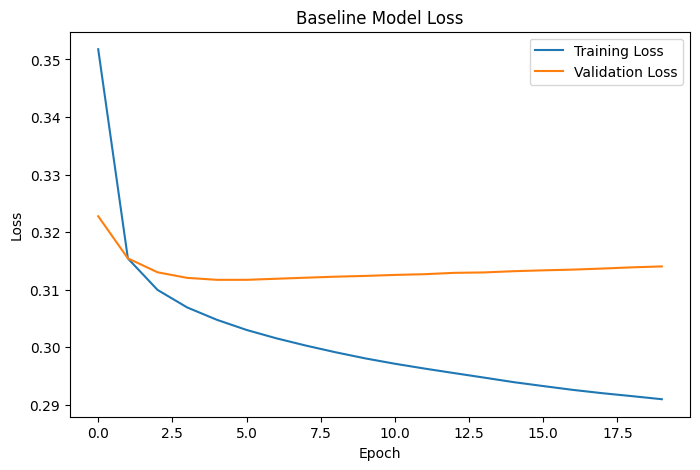

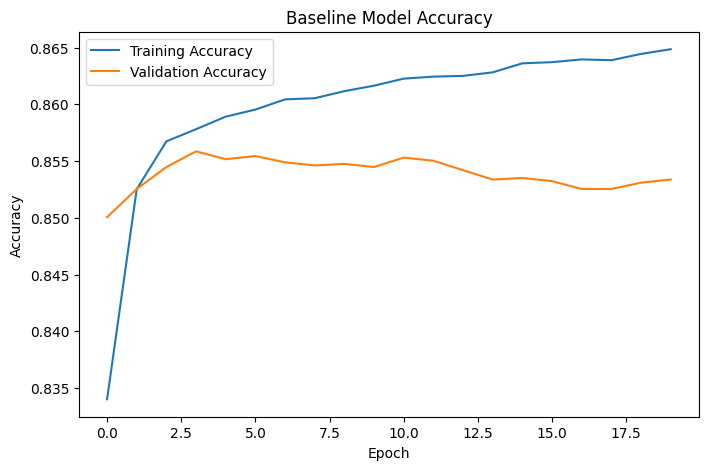

227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step


{'Accuracy': 0.853372028745163,
 'Precision': 0.7379713914174252,
 'Recall': 0.6330172894590073,
 'F1 Score': 0.6814770339237466,
 'ROC AUC': 0.911641399653807}

In [45]:
plot_training_history(baseline_history, "Baseline Model")
baseline_results = evaluate_model(baseline_model, X_val_processed, y_val)
baseline_results

In [46]:
wide_model = build_model(
    input_dim=input_dim,
    hidden_layers=[64],
    dropout_rate=0.0,
    learning_rate=0.001,
    l2_strength=0.0
)

wide_history = wide_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8405 - auc: 0.8964 - loss: 0.3380 - val_accuracy: 0.8506 - val_auc: 0.9089 - val_loss: 0.3175
Epoch 2/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8545 - auc: 0.9125 - loss: 0.3130 - val_accuracy: 0.8541 - val_auc: 0.9113 - val_loss: 0.3132
Epoch 3/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8565 - auc: 0.9150 - loss: 0.3089 - val_accuracy: 0.8561 - val_auc: 0.9120 - val_loss: 0.3119
Epoch 4/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8580 - auc: 0.9166 - loss: 0.3061 - val_accuracy: 0.8561 - val_auc: 0.9124 - val_loss: 0.3114
Epoch 5/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8596 - auc: 0.9179 - loss: 0.3038 - val_accuracy: 0.8550 - val_auc: 0.9125 - val_loss: 0.3112
Epoch 6/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8606 - auc: 0.9190 - loss: 0.3018 - val_accuracy: 0.8554 - val_auc: 0.9125 - val_loss: 0.3112
Epoch 7/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 

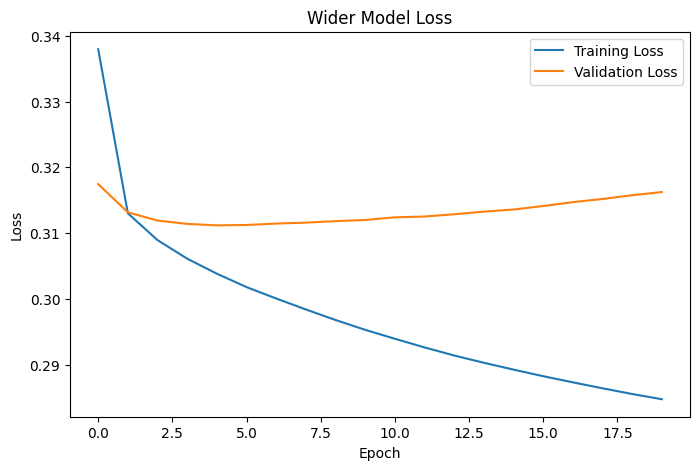

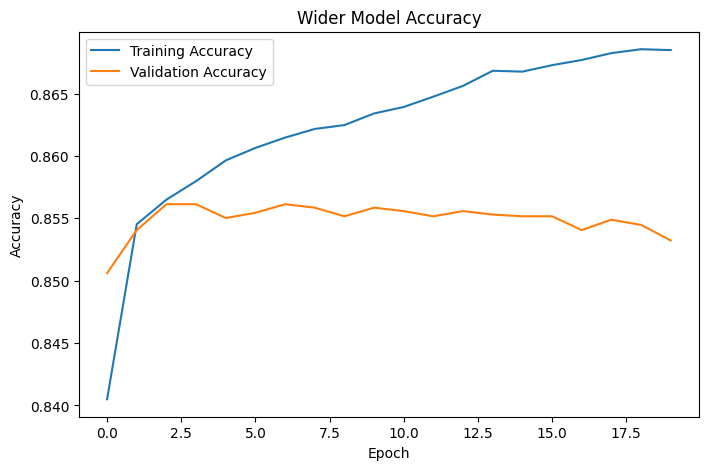

227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step


{'Accuracy': 0.8532338308457711,
 'Precision': 0.7300188797986155,
 'Recall': 0.6469604015616286,
 'F1 Score': 0.6859846244825547,
 'ROC AUC': 0.9107563975650301}

In [47]:
plot_training_history(wide_history, "Wider Model")
wide_results = evaluate_model(wide_model, X_val_processed, y_val)
wide_results

In [48]:
deep_model = build_model(
    input_dim=input_dim,
    hidden_layers=[64, 32],
    dropout_rate=0.0,
    learning_rate=0.001,
    l2_strength=0.0
)

deep_history = deep_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8414 - auc: 0.8960 - loss: 0.3379 - val_accuracy: 0.8536 - val_auc: 0.9100 - val_loss: 0.3157
Epoch 2/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8540 - auc: 0.9130 - loss: 0.3118 - val_accuracy: 0.8559 - val_auc: 0.9120 - val_loss: 0.3120
Epoch 3/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8560 - auc: 0.9158 - loss: 0.3068 - val_accuracy: 0.8563 - val_auc: 0.9123 - val_loss: 0.3111
Epoch 4/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8570 - auc: 0.9177 - loss: 0.3031 - val_accuracy: 0.8553 - val_auc: 0.9120 - val_loss: 0.3114
Epoch 5/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8585 - auc: 0.9195 - loss: 0.3000 - val_accuracy: 0.8554 - val_auc: 0.9119 - val_loss: 0.3115
Epoch 6/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8599 - auc: 0.9209 - loss: 0.2973 - val_accuracy: 0.8556 - val_auc: 0.9117 - val_loss: 0.3118
Epoch 7/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 

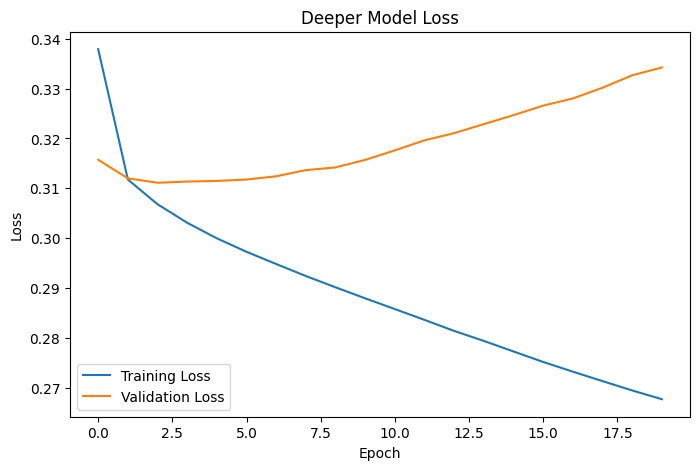

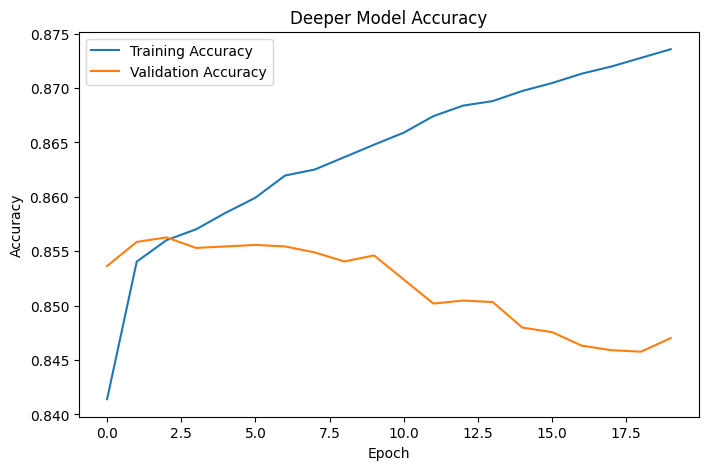

227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step


{'Accuracy': 0.8470149253731343,
 'Precision': 0.7086374695863747,
 'Recall': 0.6497490239821528,
 'F1 Score': 0.6779167878964213,
 'ROC AUC': 0.9027690410960869}

In [49]:
plot_training_history(deep_history, "Deeper Model")
deep_results = evaluate_model(deep_model, X_val_processed, y_val)
deep_results

In [50]:
regularized_model = build_model(
    input_dim=input_dim,
    hidden_layers=[64, 32],
    dropout_rate=0.30,
    learning_rate=0.001,
    l2_strength=0.001
)

regularized_history = regularized_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8325 - auc: 0.8829 - loss: 0.4160 - val_accuracy: 0.8485 - val_auc: 0.9056 - val_loss: 0.3618
Epoch 2/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8489 - auc: 0.9036 - loss: 0.3583 - val_accuracy: 0.8516 - val_auc: 0.9085 - val_loss: 0.3434
Epoch 3/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8504 - auc: 0.9060 - loss: 0.3463 - val_accuracy: 0.8527 - val_auc: 0.9092 - val_loss: 0.3365
Epoch 4/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8502 - auc: 0.9075 - loss: 0.3397 - val_accuracy: 0.8520 - val_auc: 0.9095 - val_loss: 0.3336
Epoch 5/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8524 - auc: 0.9081 - loss: 0.3366 - val_accuracy: 0.8514 - val_auc: 0.9099 - val_loss: 0.3310
Epoch 6/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8522 - auc: 0.9085 - loss: 0.3351 - val_accuracy: 0.8525 - val_auc: 0.9094 - val_loss: 0.3308
Epoch 7/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 

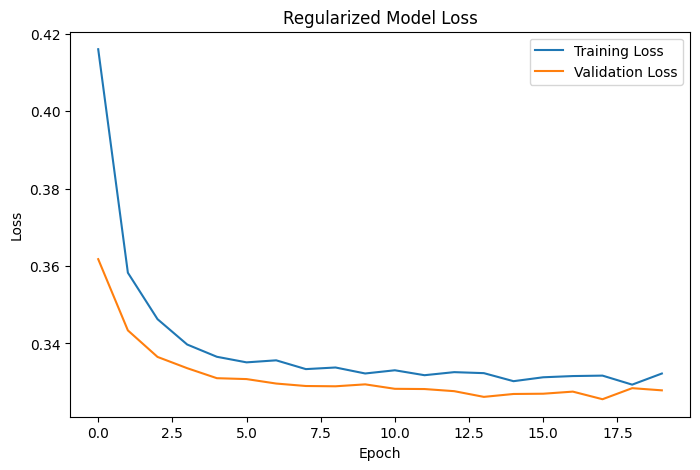

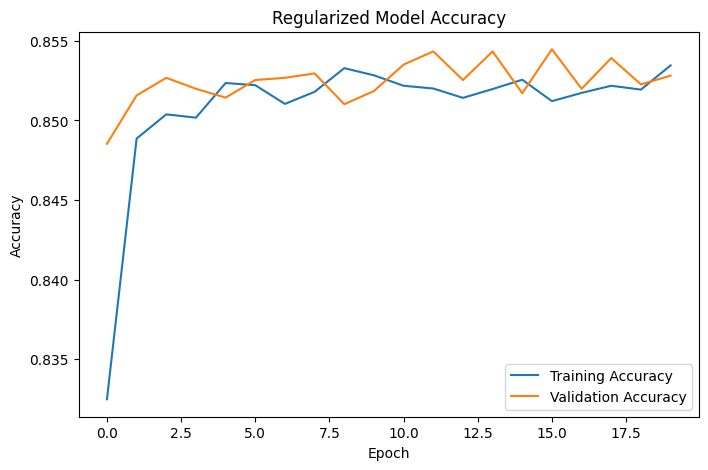

227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step


{'Accuracy': 0.8528192371475953,
 'Precision': 0.7549019607843137,
 'Recall': 0.6012269938650306,
 'F1 Score': 0.6693573424402359,
 'ROC AUC': 0.910168804132346}

In [51]:
plot_training_history(regularized_history, "Regularized Model")
regularized_results = evaluate_model(regularized_model, X_val_processed, y_val)
regularized_results

In [52]:
experiment_results = pd.DataFrame([
    {"Model": "Baseline", **baseline_results},
    {"Model": "Wider Network", **wide_results},
    {"Model": "Deeper Network", **deep_results},
    {"Model": "Regularized Network", **regularized_results}
])

experiment_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Baseline,0.853372,0.737971,0.633017,0.681477,0.911641
1,Wider Network,0.853234,0.730019,0.646960,0.685985,0.910756
2,Deeper Network,0.847015,0.708637,0.649749,0.677917,0.902769
3,Regularized Network,0.852819,0.754902,0.601227,0.669357,0.910169


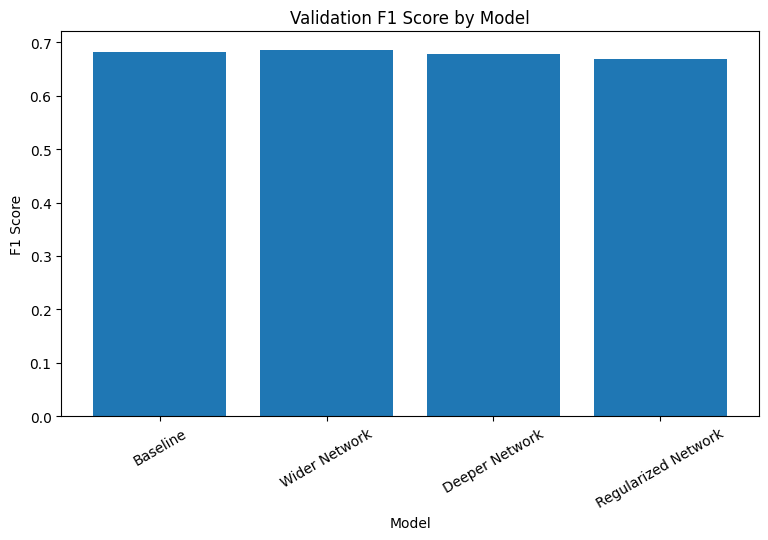

In [53]:
plt.figure(figsize=(9, 5))
plt.bar(experiment_results["Model"], experiment_results["F1 Score"])
plt.title("Validation F1 Score by Model")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.show()

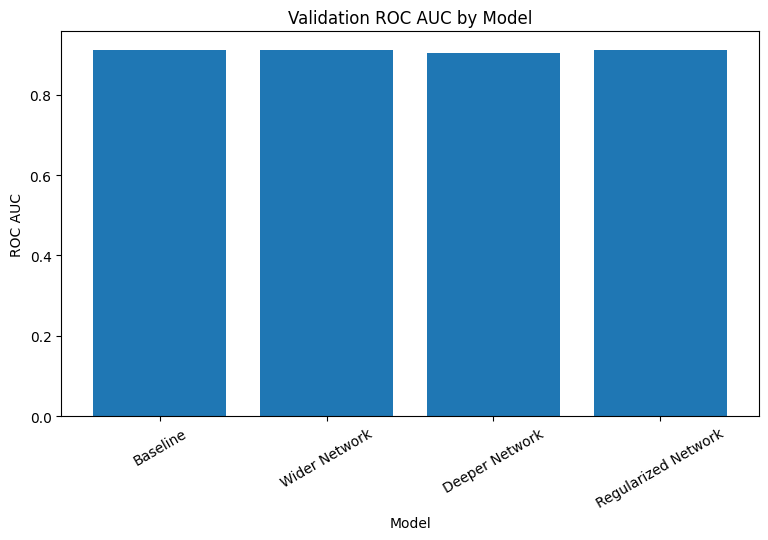

In [54]:
plt.figure(figsize=(9, 5))
plt.bar(experiment_results["Model"], experiment_results["ROC AUC"])
plt.title("Validation ROC AUC by Model")
plt.xlabel("Model")
plt.ylabel("ROC AUC")
plt.xticks(rotation=30)
plt.show()

In [55]:
param_grid = {
    "hidden_layers": [[32], [64], [64, 32]],
    "dropout_rate": [0.0, 0.2, 0.3],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32, 64]
}

grid_results = []

for params in ParameterGrid(param_grid):
    print("Training:", params)

    model = build_model(
        input_dim=input_dim,
        hidden_layers=params["hidden_layers"],
        dropout_rate=params["dropout_rate"],
        learning_rate=params["learning_rate"],
        l2_strength=0.001 if params["dropout_rate"] > 0 else 0.0
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_processed,
        y_train,
        validation_data=(X_val_processed, y_val),
        epochs=25,
        batch_size=params["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    results = evaluate_model(model, X_val_processed, y_val)

    grid_results.append({
        **params,
        **results,
        "Epochs Trained": len(history.history["loss"])
    })

grid_results_df = pd.DataFrame(grid_results)
grid_results_df.sort_values(by="F1 Score", ascending=False)

Training: {'batch_size': 32, 'dropout_rate': 0.0, 'hidden_layers': [32], 'learning_rate': 0.001}
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step
Training: {'batch_size': 32, 'dropout_rate': 0.0, 'hidden_layers': [32], 'learning_rate': 0.0005}
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step
Training: {'batch_size': 32, 'dropout_rate': 0.0, 'hidden_layers': [64], 'learning_rate': 0.001}
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step
Training: {'batch_size': 32, 'dropout_rate': 0.0, 'hidden_layers': [64], 'learning_rate': 0.0005}
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step
Training: {'batch_size': 32, 'dropout_rate': 0.0, 'hidden_layers': [64, 32], 'learning_rate': 0.001}
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step
Training: {'batch_size': 32, 'dropout_rate': 0.0, 'hidden_layers': [64, 32], 'learning_rate': 0.0005}
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step
Training: {'batch_size': 32, 'dropout_rate': 0.2, 'hidden_layers': [32], 'learning_rate': 0.001}
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step
Training:

,batch_size,dropout_rate,hidden_layers,learning_rate,Accuracy,Precision,Recall,F1 Score,ROC AUC,Epochs Trained
29,64,0.2,"[64, 32]",0.0005,0.857933,0.752475,0.635806,0.689238,0.912372,25
4,32,0.0,"[64, 32]",0.0010,0.852957,0.724861,0.655326,0.688342,0.911474,6
3,32,0.0,[64],0.0005,0.856689,0.747382,0.636921,0.687745,0.913180,13
0,32,0.0,[32],0.0010,0.855860,0.744141,0.637479,0.686693,0.913366,11
2,32,0.0,[64],0.0010,0.855583,0.743490,0.636921,0.686092,0.912287,9
19,64,0.0,[32],0.0005,0.855721,0.744611,0.635806,0.685921,0.913711,21
26,64,0.2,[64],0.0010,0.856274,0.749834,0.630229,0.684848,0.912533,25
21,64,0.0,[64],0.0005,0.855998,0.748182,0.631344,0.684815,0.913493,14
9,32,0.2,[64],0.0005,0.855169,0.743305,0.634690,0.684717,0.912616,25
18,64,0.0,[32],0.0010,0.855169,0.745227,0.631344,0.683575,0.913035,13


In [56]:
best_params = grid_results_df.sort_values(by="F1 Score", ascending=False).iloc[0]
best_params

batch_size              64
dropout_rate           0.2
hidden_layers     [64, 32]
learning_rate       0.0005
Accuracy          0.857933
Precision         0.752475
Recall            0.635806
F1 Score          0.689238
ROC AUC           0.912372
Epochs Trained          25
Name: 29, dtype: object

In [57]:
final_model = build_model(
    input_dim=input_dim,
    hidden_layers=best_params["hidden_layers"],
    dropout_rate=best_params["dropout_rate"],
    learning_rate=best_params["learning_rate"],
    l2_strength=0.001 if best_params["dropout_rate"] > 0 else 0.0
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=40,
    batch_size=int(best_params["batch_size"]),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
453/453 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8226 - auc: 0.8617 - loss: 0.4683 - val_accuracy: 0.8434 - val_auc: 0.9003 - val_loss: 0.3916
Epoch 2/40
453/453 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8451 - auc: 0.9007 - loss: 0.3822 - val_accuracy: 0.8484 - val_auc: 0.9062 - val_loss: 0.3658
Epoch 3/40
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8487 - auc: 0.9055 - loss: 0.3633 - val_accuracy: 0.8510 - val_auc: 0.9082 - val_loss: 0.3534
Epoch 4/40
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8518 - auc: 0.9078 - loss: 0.3525 - val_accuracy: 0.8524 - val_auc: 0.9098 - val_loss: 0.3451
Epoch 5/40
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8520 - auc: 0.9089 - loss: 0.3458 - val_accuracy: 0.8530 - val_auc: 0.9108 - val_loss: 0.3394
Epoch 6/40
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8545 - auc: 0.9105 - loss: 0.3400 - val_accuracy: 0.8535 - val_auc: 0.9112 - val_loss: 0.3359
Epoch 7/40
453/453 ━━━━━━━━━━━━━━━━━━━━

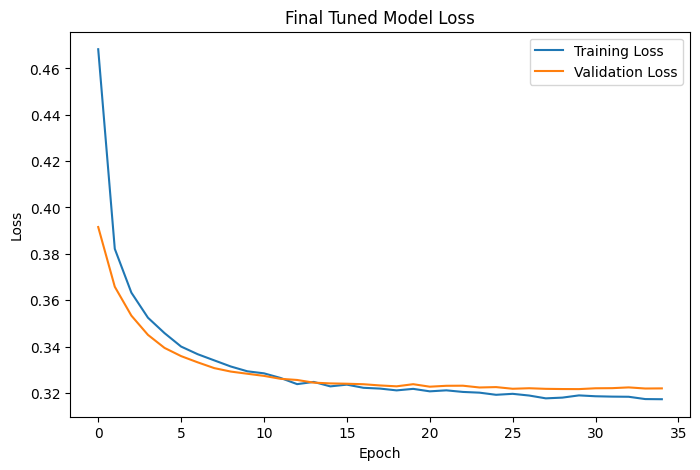

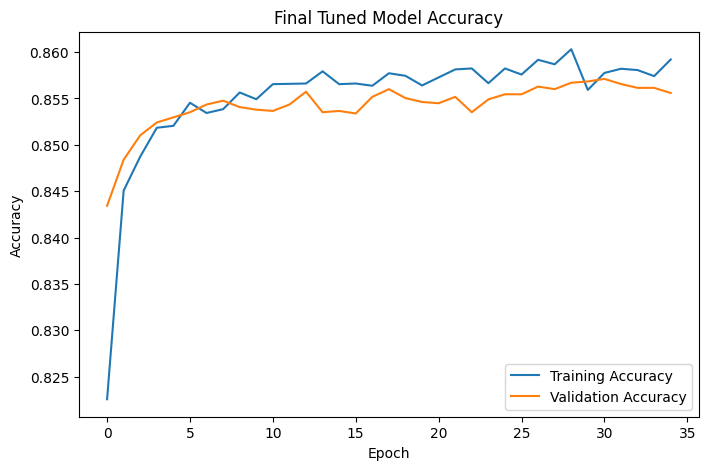

In [58]:
plot_training_history(final_history, "Final Tuned Model")

In [59]:
final_test_results = evaluate_model(final_model, X_test_processed, y_test)
final_test_results

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step


{'Accuracy': 0.8538419016030956,
 'Precision': 0.7462526766595289,
 'Recall': 0.6217662801070473,
 'F1 Score': 0.678345498783455,
 'ROC AUC': 0.9120968172329913}

In [60]:
y_test_prob = final_model.predict(X_test_processed).ravel()
y_test_pred = (y_test_prob >= 0.5).astype(int)

print(classification_report(y_test, y_test_pred))

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      6803
           1       0.75      0.62      0.68      2242

    accuracy                           0.85      9045
   macro avg       0.81      0.78      0.79      9045
weighted avg       0.85      0.85      0.85      9045



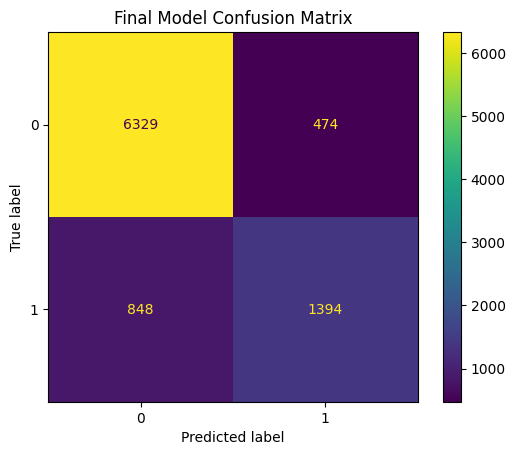

In [61]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Final Model Confusion Matrix")
plt.show()

My personal workflow for building neural networks in the future would start with making sure I understand the prediction problem and the data. Before modeling, I would identify the target variable, check whether the problem is classification or regression, and decide which metrics matter most. For this census dataset, accuracy was useful, but F1 score was more important because the income classes were imbalanced.

After understanding the problem, I would clean and prepare the dataset. This includes handling missing values, converting the target variable into the correct format, encoding categorical variables, scaling numeric variables, and adding simple engineered features when they make sense. I would also set a random seed and split the data into training, validation, and test sets before modeling so the results are reproducible and the test set stays untouched until the end.

I would then start with a simple baseline neural network instead of immediately building a complex model. The baseline gives me a starting point for comparison. From there, I would run experiments by changing one major factor at a time, such as the number of neurons, number of hidden layers, dropout rate, learning rate, or batch size. This helps me understand which changes actually improve the model instead of just making it more complicated.

While comparing models, I would look at both the performance metrics and the training/validation curves. The metrics show how well the model performs, while the curves show whether the model is learning properly, overfitting, or underfitting. In this assignment, the training and validation curves stayed fairly close together, which suggested that the final model was stable and not severely overfitting.

Once I have tested a few model designs, I would use a systematic tuning method like grid search or Optuna to find a stronger combination of hyperparameters. I would choose the final model using validation performance, then evaluate it only once on the held-out test set. The biggest best practices I would carry forward are to keep the workflow organized, avoid using the test set too early, scale the data, use early stopping, compare models fairly, and avoid adding complexity unless it leads to a meaningful improvement.

NN WORKFLOW STEPS:

1. Define the prediction goal  
Before building the model, I would identify what I am trying to predict, what type of problem it is, and which metric matters most. For this assignment, the goal was to predict whether income is above or below 50K, so it was a binary classification problem.

2. Clean and organize the data  
I would handle missing or unusual values, make sure the target variable is correctly formatted, and separate the features from the outcome variable. This step is important because poor data preparation can hurt the model before training even begins.

3. Split the data correctly  
I would create training, validation, and test sets. The training set is used to fit the model, the validation set is used to compare experiments, and the test set is saved for the final evaluation.

4. Preprocess the features  
For neural networks, I would scale numeric variables and encode categorical variables. I would also add simple engineered features when they help represent the data better.

5. Build a basic starting model  
I would begin with a simple neural network instead of starting with a complex one. This gives me a baseline to compare against and helps me see whether added complexity is actually useful.

6. Run controlled experiments  
After the baseline, I would test different model designs, such as changing the number of layers, number of neurons, dropout rate, learning rate, or batch size. I would try to change one major factor at a time so I can understand what caused the performance difference.

7. Track model behavior  
I would look at training and validation accuracy and loss curves. These curves help show whether the model is learning well, underfitting, or overfitting.

8. Tune the model systematically  
Once I know which settings seem promising, I would use grid search, Optuna, or another tuning method to compare combinations of hyperparameters more fairly.

9. Choose the final model  
I would select the final model based on validation results, not just one run. For this assignment, F1 score was important because the classes were imbalanced, but I would still consider accuracy, precision, recall, ROC AUC, and the confusion matrix.

10. Evaluate on the test set  
At the end, I would test the final model only once on the held-out test set. This gives the best estimate of how the model would perform on new data.